# Обучение и оценка модели TFT (Temporal Fusion Transformer)

В данном ноутбуке производится обучение модели TFT. 
Модель обучается по протоколу `rolling backtest` на двух горизонтах: **1 час** (краткосрочный) и **24 часа** (среднесрочный), с использованием аугментации данных (синтетические недели).

In [1]:
!git clone -b tft --single-branch https://github.com/ravil75/MetroMoscow.git
!mv MetroMoscow/{.,}* . 2>/dev/null
!rmdir MetroMoscow

Cloning into 'MetroMoscow'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 88 (delta 28), reused 82 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 233.96 KiB | 2.96 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import r2_score
import os

from src.data_prep import load_hourly, make_pivot
from src.models.tft.pipeline import predict_tft_batch, load_tft_checkpoint
from src import config

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

### 1. Запуск процесса обучения
Запускаем пайплайн обучения через командную строку. 
* **Архитектура:** `d-model=128`, `n-heads=4`, `lstm-layers=2`.
* **Окно истории:** `past-window=72` (3 суток).
* **Синтетика:** Генерируется `45` дней дополнительных данных для стабилизации весов.

In [3]:
!python -m src.models.tft.run \
  --protocol rolling \
  --min-train-1h 96 \
  --step-1h 6 \
  --min-train-24h 96 \
  --step-24h 24 \
  --train-modes real_plus_synth \
  --synth-days 45 \
  --past-window 72 \
  --d-model 128 \
  --n-heads 4 \
  --lstm-layers 2 \
  --dropout 0.1 \
  --epochs 16 \
  --batch-size 1024 \
  --synthetic-window-stride 12

Downloading...
From (original): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM
From (redirected): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM&confirm=t&uuid=7fd45f97-6f1d-4029-998b-df35fc97a276
To: /kaggle/working/data.zip
100%|██████████████████████████████████████| 2.51G/2.51G [00:27<00:00, 89.8MB/s]
chunk 10: 30,000,000 rows
chunk 20: 60,000,000 rows
chunk 30: 89,150,313 rows
saved: /kaggle/working/eda_output/hourly.parquet (266,213 rows)
saved: /kaggle/working/eda_output/object_hourly.parquet (216,346 rows)
/kaggle/working/src/clustering.py:94: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  features = pd.concat(parts, ignore_index=True)
saved: /kaggle/working/eda_output/final_clusters.csv (5 cluster

### 2. Базовые метрики качества (Среднее по всем фолдам кросс-валидации)
Загружаем результаты бэктеста. Здесь представлено усредненное значение MAE, SMAPE и WAPE по всем тестовым окнам, которые прошла модель в процессе скользящего обучения.

In [7]:
summary_1h = pd.read_csv('eda_output/tft_summary_1h.csv')
summary_24h = pd.read_csv('eda_output/tft_summary_24h.csv')

print("Горизонт 1 час")
display(summary_1h[['train_mode', 'MAE', 'SMAPE', 'WAPE']])

print("\nГоризонт 24 часа")
display(summary_24h[['train_mode', 'MAE', 'SMAPE', 'WAPE']])

Горизонт 1 час


,train_mode,MAE,SMAPE,WAPE
0,real_plus_synth,39.4688,24.6168,13.9675



Горизонт 24 часа


,train_mode,MAE,SMAPE,WAPE
0,real_plus_synth,49.5533,31.4291,23.7374


### 3. Визуализация процесса обучения

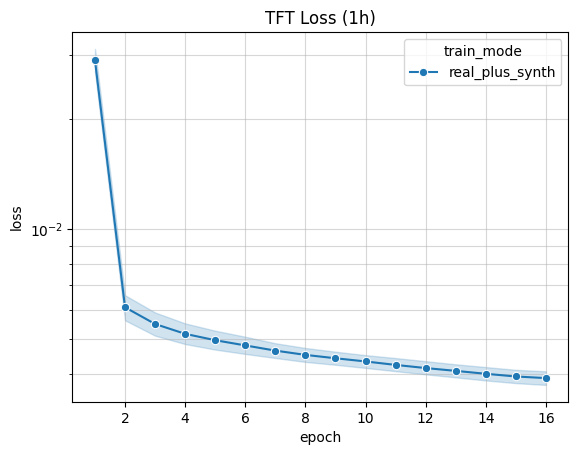

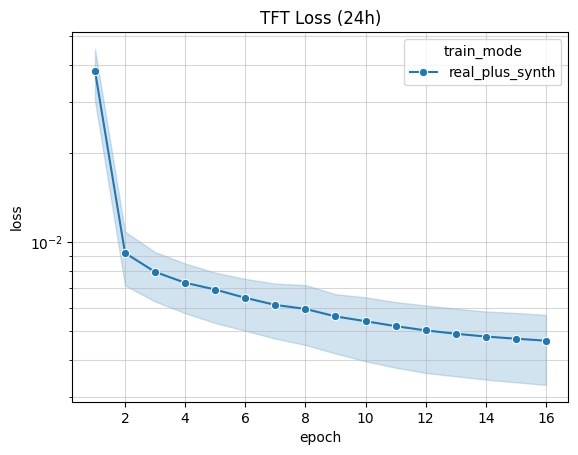

In [8]:
for horizon in [1, 24]:
    history = pd.read_csv(f'eda_output/tft_history_{horizon}h.csv')
    plt.figure()
    sns.lineplot(data=history, x='epoch', y='loss', hue='train_mode', marker='o')
    plt.title(f'TFT Loss ({horizon}h)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

### 4. Оценка качества сгенерированных синтетических данных


In [10]:
metrics_cols = ['acf_similarity', 'profile_corr', 'quantile_ratio', 'corr_mae']

for horizon in [1, 24]:
    synth_val = pd.read_csv(f'eda_output/tft_synth_validation_{horizon}h.csv')
    print(f"\nГоризонт {horizon}h")
    display(synth_val[metrics_cols].mean().to_frame('mean'))


Горизонт 1h


,mean
acf_similarity,0.939262
profile_corr,0.992074
quantile_ratio,0.896450
corr_mae,0.033266



Горизонт 24h


,mean
acf_similarity,0.939262
profile_corr,0.992074
quantile_ratio,0.896450
corr_mae,0.033266


### 5. Анализ аномалий: Топ-10 самых сложных маршрутов/станций


In [11]:
clusters = pd.read_csv('eda_output/final_clusters.csv')

for horizon in [1, 24]:
    results = pd.read_csv(f'eda_output/tft_results_{horizon}h.csv')

    top_errors = results[results['train_mode'] == 'real_plus_synth'] \
        .groupby('object_id')['WAPE'].mean() \
        .sort_values(ascending=False).head(10)

    report = top_errors.to_frame().merge(
        clusters[['object_id_str', 'object_name', 'cluster_name']],
        left_index=True, right_on='object_id_str',
        how='left'
    )

    print(f"\nТоп-10 сложных объектов для TFT ({horizon}h)")
    display(report[['object_name', 'cluster_name', 'WAPE']])


Топ-10 сложных объектов для TFT (1h)


,object_name,cluster_name,WAPE
148.0,Терехово,Business medium,115.499086
1141.0,Моторы Войны Экс П12Л25,Mixed medium (NGPT),53.587600
669.0,NGPT_4963.0,Mixed medium (NGPT),50.178600
995.0,113 автобус,Mixed medium (NGPT),48.029600
1204.0,NGPT_6679.0,Mixed medium (NGPT),47.090400
1370.0,Савеловское 2002077 МАРК,Residential medium,45.935500
NaN,NaN,NaN,45.529700
735.0,623 автобус,Mixed medium (NGPT),45.438500
NaN,NaN,NaN,45.017800
1309.0,Белорусское 2000700 ТЕСТОВСКАЯ (Москва-Сити),Business medium,44.674000



Топ-10 сложных объектов для TFT (24h)


,object_name,cluster_name,WAPE
800,NGPT_6554.0,Mixed medium (NGPT),1275.942733
728,NGPT_6160.0,Mixed medium (NGPT),788.615800
763,NGPT_6333.0,Mixed medium (NGPT),285.931967
1182,NGPT_6321.0,Residential medium,146.373833
1185,NGPT_6360.0,Mixed medium (NGPT),145.960833
1188,NGPT_6386.0,Mixed medium (NGPT),81.395767
1171,518 автобус,Residential medium,71.936350
1035,NGPT_3932.0,Residential medium,71.296950
1254,NGPT_4419.0,Mixed medium (NGPT),69.059050
708,NGPT_6038.0,Mixed medium (NGPT),67.910967


### 6. Метрики (по последним, наиболее обученным фолдам)


In [12]:
def get_mature_metrics(df, horizon_name):
    max_fold = df['fold'].max()
    mature_df = df[df['fold'] >= max_fold - 1]

    stats = mature_df.groupby('train_mode').agg(
        MAE=('MAE', 'mean'),
        SMAPE=('SMAPE', 'mean'),
        WAPE=('WAPE', 'mean')
    ).round(2)

    stats['horizon'] = horizon_name
    return stats.reset_index()

mature_1h = get_mature_metrics(pd.read_csv('eda_output/tft_results_1h.csv'), '1h')
mature_24h = get_mature_metrics(pd.read_csv('eda_output/tft_results_24h.csv'), '24h')

final_report = pd.concat([mature_1h, mature_24h])[['horizon', 'train_mode', 'MAE', 'SMAPE', 'WAPE']]
display(final_report)

,horizon,train_mode,MAE,SMAPE,WAPE
0,1h,real_plus_synth,36.38,20.08,13.08
0,24h,real_plus_synth,46.50,34.08,26.90


### 7. Итоговая проверка сохраненных весов модели на полном датасете
Подгружаем сохраненные `.pt` чекпойнты финальных моделей и прогоняем их через весь датасет. 

**Важно:** Данный прогон включает *data leakage* (модель предсказывает участки данных, на которых уже обучалась). Это финальный sanity-check (проверка на адекватность), позволяющий оценить верхнюю границу возможностей архитектуры.

In [17]:
hourly = load_hourly()
pivot = make_pivot(hourly, top_n=1500)
print(f"Датасет: {pivot.shape[0]} часов x {pivot.shape[1]} объектов")

Датасет: 168 часов x 1500 объектов


In [22]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.maximum(np.asarray(y_pred, dtype=float).ravel(), 0.0)

    mae = np.mean(np.abs(y_true - y_pred))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / max(np.sum(np.abs(y_true)), 1.0) * 100
    r2 = r2_score(y_true, y_pred)

    return {"MAE": round(mae, 4), "SMAPE": round(smape, 4), "WAPE": round(wape, 4), "R2": round(r2, 4)}

def evaluate_on_full_dataset(pivot_df, model, scales, cfg, horizon, step=None):
    step = step or horizon
    n = len(pivot_df)
    all_true, all_pred = [], []

    starts = list(range(cfg.past_window, n - horizon + 1, step))
    print(f"  h={horizon}: {len(starts)} окон для оценки")

    for start in starts:
        history_frame = pivot_df.iloc[:start]
        y_true_df = pivot_df.iloc[start : start + horizon]
        target_index = y_true_df.index

        pred_df = predict_tft_batch(model, history_frame, target_index, scales, cfg)

        all_true.append(y_true_df.values.ravel())
        all_pred.append(pred_df.values.ravel())

    return compute_metrics(np.concatenate(all_true), np.concatenate(all_pred))

In [23]:
TRAIN_MODE = "real_plus_synth"
PROTOCOL = "rolling"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []

for horizon in [1, 24]:
    filename = f"tft_model_{PROTOCOL}_{TRAIN_MODE}_h{horizon}.pt"
    model_path = config.OUTPUT_DIR / filename

    if not model_path.exists():
        print(f"Файл {model_path} не найден, пропускаем h={horizon}")
        continue

    print(f"\nГоризонт {horizon}h")

    try:
        model, scales, trained_cfg = load_tft_checkpoint(model_path, device=device)
        print(f"  Загружена модель (past_window={trained_cfg.past_window})")
    except Exception as e:
        print(f"  Ошибка загрузки: {e}")
        continue

    eval_step = 1 if horizon == 1 else 24
    metrics = evaluate_on_full_dataset(pivot, model, scales, trained_cfg, horizon, step=eval_step)
    metrics["horizon"] = f"{horizon}h"
    results.append(metrics)

    print(f"  Результат: {metrics}")

if results:
    summary_df = pd.DataFrame(results)[["horizon", "MAE", "SMAPE", "WAPE", "R2"]]
    print("\nИтоговые метрики (весь период, включает data leakage)")
    display(summary_df)
else:
    print("Нет результатов для отображения.")


Горизонт 1h
  Загружена модель (past_window=72)
  h=1: 96 окон для оценки
  Результат: {'MAE': np.float64(28.4192), 'SMAPE': np.float64(35.2903), 'WAPE': np.float64(10.6933), 'R2': 0.9799, 'horizon': '1h'}

Горизонт 24h
  Загружена модель (past_window=72)
  h=24: 4 окон для оценки
  Результат: {'MAE': np.float64(31.5596), 'SMAPE': np.float64(45.1115), 'WAPE': np.float64(11.875), 'R2': 0.9786, 'horizon': '24h'}

Итоговые метрики (весь период, включает data leakage)


,horizon,MAE,SMAPE,WAPE,R2
0,1h,28.4192,35.2903,10.6933,0.9799
1,24h,31.5596,45.1115,11.8750,0.9786


### Итоговые выводы: сравнение моделей (TCN vs N-BEATS vs TFT)

По результатам экспериментов **лидером становится модель TFT (Temporal Fusion Transformer)**.

* **Горизонт 1 час:** 
  Все три архитектуры неплохо справляются с задачей, показывая на последних фолдах сопоставимый WAPE (~12.6–13.1%). На полном датасете TFT достигает точности **WAPE = 10.69%** и **R² = 0.9799**.
  
* **Горизонт 24 часа (Среднесрочный прогноз):** 
  Именно здесь TFT показал свое превосходство. Благодаря механизмам Attention и отбору признаков (VSN), модель лучше уловила суточную сезонность, снизив ошибку **WAPE до 26.9%** (против ~30.1% у TCN и 30.8% у N-BEATS). На полном датасете R² составил **0.978**.

* **Анализ аномалий:** 
  У всех моделей гигантские ошибки (до 1200%) сконцентрированы на одних и тех же автобусных маршрутах (NGPT). Возможно - это следствие непредсказуемых внешних факторов (сбои, перекрытия, поломки валидаторов), когда реальный поток падает до нуля. Метро при этом предсказывается достаточно точно. TFT фильтрует этот транспортный шум лучше конкурентов.

**Резюме:** TFT наиболее устойчив к выбросам и лучше экстраполирует сложные паттерны на сутки вперед. Пока, что эта архитектура утверждается как оптимальное решение задачи проекта.